In [ ]:
# ==============================================
# STEP 1: Upload your ZIP file manually
# ==============================================
from google.colab import files
uploaded = files.upload()  # <-- pick your punjabi zip file here (e.g., punjabi-Non discard.zip)

# get the filename from the uploaded dict
zip_filename = list(uploaded.keys())[0]
print("Uploaded:", zip_filename)

# ==============================================
# STEP 2: Extract the ZIP
# ==============================================
import os, zipfile

extract_dir = "/content/punjabi_dataset_extracted"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall(extract_dir)

print("✅ Extraction done at:", extract_dir)

# ==============================================
# STEP 3: Create metadata CSV (detect participant & emotion)
# ==============================================
import pandas as pd, re, json

# Find dataset root (if it has a single folder inside, go inside it)
entries = [e for e in os.listdir(extract_dir) if not e.startswith("__")]
if len(entries) == 1 and os.path.isdir(os.path.join(extract_dir, entries[0])):
    dataset_root = os.path.join(extract_dir, entries[0])
else:
    dataset_root = extract_dir

print("Dataset root:", dataset_root)

audio_exts = {'.wav', '.mp3', '.flac', '.ogg', '.m4a', '.aac'}
rows = []

for root, dirs, files in os.walk(dataset_root):
    for f in files:
        ext = os.path.splitext(f)[1].lower()
        if ext in audio_exts:
            full = os.path.join(root, f)
            rel = os.path.relpath(full, dataset_root)
            parts = rel.split(os.sep)

            # find participant name
            p_idx = None
            for i, part in enumerate(parts):
                if re.search(r'participant\s*\d+', part, re.I):
                    p_idx = i
                    break
            participant = parts[p_idx] if p_idx is not None else parts[0]

            # find emotion (usually next folder after participant or parent folder)
            if p_idx is not None and p_idx + 1 < len(parts):
                emotion = parts[p_idx + 1]
            else:
                emotion = parts[-2] if len(parts) >= 2 else 'unknown'

            rows.append({
                "filepath": full,
                "relpath": rel,
                "participant": participant,
                "emotion": emotion,
                "file_name": f,
                "extension": ext
            })

df = pd.DataFrame(rows)
print("Total files found:", len(df))

# ==============================================
# STEP 4: Clean emotion labels
# ==============================================
def normalize_emotion(s):
    s = '' if pd.isna(s) else str(s)
    s = re.sub(r'^\s*\d+\s*[\.\)\-]*\s*', '', s).strip().lower()
    if 'ang' in s: return 'anger'
    if 'fear' in s: return 'fear'
    if 'happy' in s: return 'happy'
    if 'neutral' in s: return 'neutral'
    if 'sad' in s: return 'sad'
    return s

df['emotion_clean'] = df['emotion'].apply(normalize_emotion)

emotions = sorted(df['emotion_clean'].unique())
label_map = {emo: i for i, emo in enumerate(emotions)}
df['label_id'] = df['emotion_clean'].map(label_map)

print("Detected emotion classes:", emotions)
print(df['emotion_clean'].value_counts())

# ==============================================
# STEP 5: Save cleaned metadata
# ==============================================
csv_path = "/content/punjabi_metadata_clean.csv"
json_path = "/content/punjabi_label_map.json"

df.to_csv(csv_path, index=False)
with open(json_path, 'w') as f:
    json.dump(label_map, f, indent=2)

print("✅ Saved cleaned CSV ->", csv_path)
print("✅ Saved label map ->", json_path)

# Preview
df.head()


Saving punjabi-Non discard-20251008T032331Z-1-001.zip to punjabi-Non discard-20251008T032331Z-1-001.zip
Uploaded: punjabi-Non discard-20251008T032331Z-1-001.zip
✅ Extraction done at: /content/punjabi_dataset_extracted
Dataset root: /content/punjabi_dataset_extracted/punjabi-Non discard
Total files found: 1240
Detected emotion classes: ['anger', 'fear', 'happy', 'neutral', 'sad']
emotion_clean
happy      252
anger      251
neutral    251
sad        249
fear       237
Name: count, dtype: int64
✅ Saved cleaned CSV -> /content/punjabi_metadata_clean.csv
✅ Saved label map -> /content/punjabi_label_map.json


,filepath,relpath,participant,emotion,file_name,extension,emotion_clean,label_id
0,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 11/4. Angry /14.4.mp3,Participant 11,4. Angry,14.4.mp3,.mp3,anger,0
1,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 11/4. Angry /3.4.mp3,Participant 11,4. Angry,3.4.mp3,.mp3,anger,0
2,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 11/4. Angry /15.4.mp3,Participant 11,4. Angry,15.4.mp3,.mp3,anger,0
3,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 11/4. Angry /8.4.mp3,Participant 11,4. Angry,8.4.mp3,.mp3,anger,0
4,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 11/4. Angry /9.4.mp3,Participant 11,4. Angry,9.4.mp3,.mp3,anger,0


In [ ]:
import pandas as pd

# Load the cleaned metadata CSV
df = pd.read_csv('/content/punjabi_metadata_clean.csv')

# One-hot encode the emotion column
emotion_encoded = pd.get_dummies(df['emotion_clean'], prefix='emotion')

# Combine with original metadata (optional)
df_encoded = pd.concat([df, emotion_encoded], axis=1)

# Drop old emotion column if you want
# df_encoded.drop('emotion_clean', axis=1, inplace=True)

print(df_encoded.head())

# Save encoded version (optional)
df_encoded.to_csv('/content/punjabi_metadata_encoded.csv', index=False)


                                            filepath  \
0  /content/punjabi_dataset_extracted/punjabi-Non...   
1  /content/punjabi_dataset_extracted/punjabi-Non...   
2  /content/punjabi_dataset_extracted/punjabi-Non...   
3  /content/punjabi_dataset_extracted/punjabi-Non...   
4  /content/punjabi_dataset_extracted/punjabi-Non...   

                             relpath     participant    emotion file_name  \
0  Participant 11/4. Angry /14.4.mp3  Participant 11  4. Angry   14.4.mp3   
1   Participant 11/4. Angry /3.4.mp3  Participant 11  4. Angry    3.4.mp3   
2  Participant 11/4. Angry /15.4.mp3  Participant 11  4. Angry   15.4.mp3   
3   Participant 11/4. Angry /8.4.mp3  Participant 11  4. Angry    8.4.mp3   
4   Participant 11/4. Angry /9.4.mp3  Participant 11  4. Angry    9.4.mp3   

  extension emotion_clean  label_id  emotion_anger  emotion_fear  \
0      .mp3         anger         0           True         False   
1      .mp3         anger         0           True         False

In [ ]:
# ======================================
# STEP 2: Feature Extraction
# ======================================

!pip install librosa soundfile tqdm --quiet

import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm

# Load your one-hot encoded metadata
df = pd.read_csv('/content/punjabi_metadata_encoded.csv')

# Function to extract multiple features
def extract_audio_features(file_path, sr=16000):
    try:
        y, sr = librosa.load(file_path, sr=sr, mono=True)

        # Feature 1: MFCC (mean + std)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)

        # Feature 2: Chroma
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)
        chroma_std = np.std(chroma, axis=1)

        # Feature 3: Spectral Contrast
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        contrast_mean = np.mean(contrast, axis=1)
        contrast_std = np.std(contrast, axis=1)

        # Feature 4: Zero-Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y)
        zcr_mean = np.mean(zcr)

        # Feature 5: RMS energy
        rms = librosa.feature.rms(y=y)
        rms_mean = np.mean(rms)

        # Combine all features into one vector
        features = np.concatenate([mfcc_mean, mfcc_std,
                                   chroma_mean, chroma_std,
                                   contrast_mean, contrast_std,
                                   [zcr_mean, rms_mean]])
        return features
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return np.zeros(80)  # placeholder if file fails

# Extract features for all files
feature_list = []
for path in tqdm(df['filepath'], desc="Extracting features"):
    feats = extract_audio_features(path)
    feature_list.append(feats)

# Create dataframe
features_df = pd.DataFrame(feature_list)
features_df.columns = [f"f_{i}" for i in range(features_df.shape[1])]

# Combine with labels (One-hot encoded columns)
label_cols = [col for col in df.columns if col.startswith("emotion_")]
final_df = pd.concat([features_df, df[label_cols]], axis=1)

# Save to CSV
final_df.to_csv("/content/punjabi_audio_features.csv", index=False)
print("✅ Feature extraction complete! Saved to /content/punjabi_audio_features.csv")

final_df.head()


Extracting features: 100%|██████████| 1240/1240 [01:17<00:00, 16.00it/s]


✅ Feature extraction complete! Saved to /content/punjabi_audio_features.csv


,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,...,f_62,f_63,f_64,f_65,emotion_clean,emotion_anger,emotion_fear,emotion_happy,emotion_neutral,emotion_sad
0,-318.921967,60.507885,-15.521299,14.283187,0.202756,-10.631938,-17.285044,-7.605762,-8.279307,0.555486,...,4.479901,3.758297,0.107833,0.053588,anger,True,False,False,False,False
1,-280.951721,73.030289,-8.622173,28.299177,5.964883,-8.721054,-2.551167,-12.862445,-7.322230,1.731831,...,9.063779,4.075496,0.125742,0.068960,anger,True,False,False,False,False
2,-285.831329,63.247940,0.862079,14.560561,0.513072,-4.030958,-10.150605,-0.360010,-3.569650,-2.269853,...,4.618494,3.739073,0.130703,0.070978,anger,True,False,False,False,False
3,-281.271393,91.911880,-6.829667,13.323407,1.385942,0.544643,-13.025861,-7.845757,-5.234655,4.728014,...,5.084978,3.704315,0.104599,0.064020,anger,True,False,False,False,False
4,-265.801514,71.718620,-8.514792,20.744820,-1.934391,-8.751799,-4.349576,-14.511599,-8.377314,2.565222,...,6.910395,4.145968,0.113906,0.082455,anger,True,False,False,False,False


In [ ]:
# Re-extract features with identifiers stored
!pip install librosa soundfile tqdm --quiet

import librosa, numpy as np, pandas as pd
from tqdm import tqdm

meta = pd.read_csv('/content/punjabi_metadata_clean.csv')   # must exist
meta = meta.reset_index(drop=True)

def extract_audio_features(file_path, sr=16000):
    try:
        y, sr = librosa.load(file_path, sr=sr, mono=True)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)
        chroma_std = np.std(chroma, axis=1)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        contrast_mean = np.mean(contrast, axis=1)
        contrast_std = np.std(contrast, axis=1)
        zcr_mean = np.mean(librosa.feature.zero_crossing_rate(y))
        rms_mean = np.mean(librosa.feature.rms(y=y))
        features = np.concatenate([mfcc_mean, mfcc_std, chroma_mean, chroma_std,
                                   contrast_mean, contrast_std, [zcr_mean, rms_mean]])
        return features
    except Exception as e:
        print("Error:", file_path, e)
        return np.full(13*2 + 12*2 + 7*2 + 2, np.nan)  # adjust length if you changed features

# run extraction while keeping identifiers
rows = []
for idx, row in tqdm(meta.iterrows(), total=len(meta)):
    path = row['filepath']
    feats = extract_audio_features(path)
    # create dict of feature values with names
    feat_dict = {f"f_{i}": float(feats[i]) for i in range(len(feats))}
    # attach identifiers
    feat_dict.update({
        'filepath': path,
        'relpath': row.get('relpath', ''),
        'participant': row.get('participant',''),
        'file_name': row.get('file_name',''),
        'emotion_clean': row.get('emotion_clean',''),
        'label_id': row.get('label_id', -1)
    })
    rows.append(feat_dict)

features_with_ids = pd.DataFrame(rows)
features_with_ids.to_csv('/content/punjabi_audio_features_with_ids.csv', index=False)
print("Saved /content/punjabi_audio_features_with_ids.csv with", features_with_ids.shape[0], "rows.")
features_with_ids.head()


100%|██████████| 1240/1240 [01:01<00:00, 20.20it/s]


Saved /content/punjabi_audio_features_with_ids.csv with 1240 rows.


,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,...,f_62,f_63,f_64,f_65,filepath,relpath,participant,file_name,emotion_clean,label_id
0,-318.921967,60.507885,-15.521299,14.283187,0.202756,-10.631938,-17.285044,-7.605762,-8.279307,0.555486,...,4.479901,3.758297,0.107833,0.053588,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 11/4. Angry /14.4.mp3,Participant 11,14.4.mp3,anger,0
1,-280.951721,73.030289,-8.622173,28.299177,5.964883,-8.721054,-2.551167,-12.862445,-7.322230,1.731831,...,9.063779,4.075496,0.125742,0.068960,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 11/4. Angry /3.4.mp3,Participant 11,3.4.mp3,anger,0
2,-285.831329,63.247940,0.862079,14.560561,0.513072,-4.030958,-10.150605,-0.360010,-3.569650,-2.269853,...,4.618494,3.739073,0.130703,0.070978,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 11/4. Angry /15.4.mp3,Participant 11,15.4.mp3,anger,0
3,-281.271393,91.911880,-6.829667,13.323407,1.385942,0.544643,-13.025861,-7.845757,-5.234655,4.728014,...,5.084978,3.704315,0.104599,0.064020,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 11/4. Angry /8.4.mp3,Participant 11,8.4.mp3,anger,0
4,-265.801514,71.718620,-8.514792,20.744820,-1.934391,-8.751799,-4.349576,-14.511599,-8.377314,2.565222,...,6.910395,4.145968,0.113906,0.082455,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 11/4. Angry /9.4.mp3,Participant 11,9.4.mp3,anger,0


In [ ]:
import pandas as pd
import numpy as np

# Load your extracted features CSV
df = pd.read_csv("/content/punjabi_audio_features_with_ids.csv")

print("Shape:", df.shape)
df.head()


Shape: (1240, 72)


,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,...,f_62,f_63,f_64,f_65,filepath,relpath,participant,file_name,emotion_clean,label_id
0,-318.921967,60.507885,-15.521299,14.283187,0.202756,-10.631938,-17.285044,-7.605762,-8.279307,0.555486,...,4.479901,3.758297,0.107833,0.053588,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 11/4. Angry /14.4.mp3,Participant 11,14.4.mp3,anger,0
1,-280.951721,73.030289,-8.622173,28.299177,5.964883,-8.721054,-2.551167,-12.862445,-7.322230,1.731831,...,9.063779,4.075496,0.125742,0.068960,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 11/4. Angry /3.4.mp3,Participant 11,3.4.mp3,anger,0
2,-285.831329,63.247940,0.862079,14.560561,0.513072,-4.030958,-10.150605,-0.360010,-3.569650,-2.269853,...,4.618494,3.739073,0.130703,0.070978,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 11/4. Angry /15.4.mp3,Participant 11,15.4.mp3,anger,0
3,-281.271393,91.911880,-6.829667,13.323407,1.385942,0.544643,-13.025861,-7.845757,-5.234655,4.728014,...,5.084978,3.704315,0.104599,0.064020,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 11/4. Angry /8.4.mp3,Participant 11,8.4.mp3,anger,0
4,-265.801514,71.718620,-8.514792,20.744820,-1.934391,-8.751799,-4.349576,-14.511599,-8.377314,2.565222,...,6.910395,4.145968,0.113906,0.082455,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 11/4. Angry /9.4.mp3,Participant 11,9.4.mp3,anger,0


In [ ]:
# Identify numeric feature columns (f_0, f_1, ... etc.)
feature_cols = [c for c in df.columns if c.startswith("f_")]
X = df[feature_cols]

# Identify emotion label columns
label_cols = [c for c in df.columns if c.startswith("emotion_")]
y = df[label_cols] if label_cols else df["emotion_clean"]

print("Features shape:", X.shape)
print("Labels shape:", y.shape)


Features shape: (1240, 66)
Labels shape: (1240, 1)


#EDA

In [ ]:
import pandas as pd
import numpy as np

# Load your extracted feature dataset
df = pd.read_csv('/content/punjabi_audio_features_with_ids.csv')
print("Shape:", df.shape)
df.head()


Shape: (1240, 72)


,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,...,f_62,f_63,f_64,f_65,filepath,relpath,participant,file_name,emotion_clean,label_id
0,-318.921967,60.507885,-15.521299,14.283187,0.202756,-10.631938,-17.285044,-7.605762,-8.279307,0.555486,...,4.479901,3.758297,0.107833,0.053588,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 11/4. Angry /14.4.mp3,Participant 11,14.4.mp3,anger,0
1,-280.951721,73.030289,-8.622173,28.299177,5.964883,-8.721054,-2.551167,-12.862445,-7.322230,1.731831,...,9.063779,4.075496,0.125742,0.068960,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 11/4. Angry /3.4.mp3,Participant 11,3.4.mp3,anger,0
2,-285.831329,63.247940,0.862079,14.560561,0.513072,-4.030958,-10.150605,-0.360010,-3.569650,-2.269853,...,4.618494,3.739073,0.130703,0.070978,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 11/4. Angry /15.4.mp3,Participant 11,15.4.mp3,anger,0
3,-281.271393,91.911880,-6.829667,13.323407,1.385942,0.544643,-13.025861,-7.845757,-5.234655,4.728014,...,5.084978,3.704315,0.104599,0.064020,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 11/4. Angry /8.4.mp3,Participant 11,8.4.mp3,anger,0
4,-265.801514,71.718620,-8.514792,20.744820,-1.934391,-8.751799,-4.349576,-14.511599,-8.377314,2.565222,...,6.910395,4.145968,0.113906,0.082455,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 11/4. Angry /9.4.mp3,Participant 11,9.4.mp3,anger,0


In [ ]:
# Feature columns (numerical)
feature_cols = [c for c in df.columns if c.startswith('f_')]
X = df[feature_cols]

# Label columns (emotion)
if 'emotion_clean' in df.columns:
    y = df['emotion_clean']
else:
    y = [c for c in df.columns if c.startswith('emotion_')]
    y = df[y].idxmax(axis=1).str.replace('emotion_', '')  # if one-hot

print("Total features:", len(feature_cols))
print("Total samples:", len(X))
print("Unique emotions:", y.unique())


Total features: 66
Total samples: 1240
Unique emotions: ['anger' 'fear' 'sad' 'neutral' 'happy']


In [ ]:
print("Missing values per column:", X.isna().sum().sum())
print("\nSummary statistics:")
display(X.describe().T.head(10))


Missing values per column: 0

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
f_0,1240.0,-297.058932,61.142333,-521.813477,-327.958168,-291.245026,-254.538147,-155.454681
f_1,1240.0,96.039987,24.169968,16.786276,80.847322,98.396103,111.386747,172.306122
f_2,1240.0,-4.535144,16.764841,-59.640156,-15.454297,-5.191326,7.065100,39.958683
f_3,1240.0,24.311086,11.676422,-12.991163,17.329607,24.924575,31.949992,57.600735
f_4,1240.0,-10.503719,14.670368,-62.588139,-19.242582,-8.271582,-0.096850,27.426609
f_5,1240.0,-3.094542,11.105122,-38.273323,-10.697141,-2.229157,4.964612,30.232233
f_6,1240.0,-8.585642,10.411624,-52.943623,-13.579733,-6.843013,-1.195095,23.337132
f_7,1240.0,-1.158322,8.339330,-26.860485,-6.809323,-2.009161,4.331924,25.643087
f_8,1240.0,-5.532642,7.570677,-26.170925,-10.797788,-5.649551,-0.752919,23.861996
f_9,1240.0,-5.346890,7.132766,-26.158270,-9.951707,-5.732820,-0.768644,16.414377


Visualizing feature distribution for these selected features:
['f_18', 'f_13', 'f_1', 'f_26', 'f_27', 'f_29', 'f_41', 'f_46', 'f_47', 'f_50', 'f_58', 'f_53']


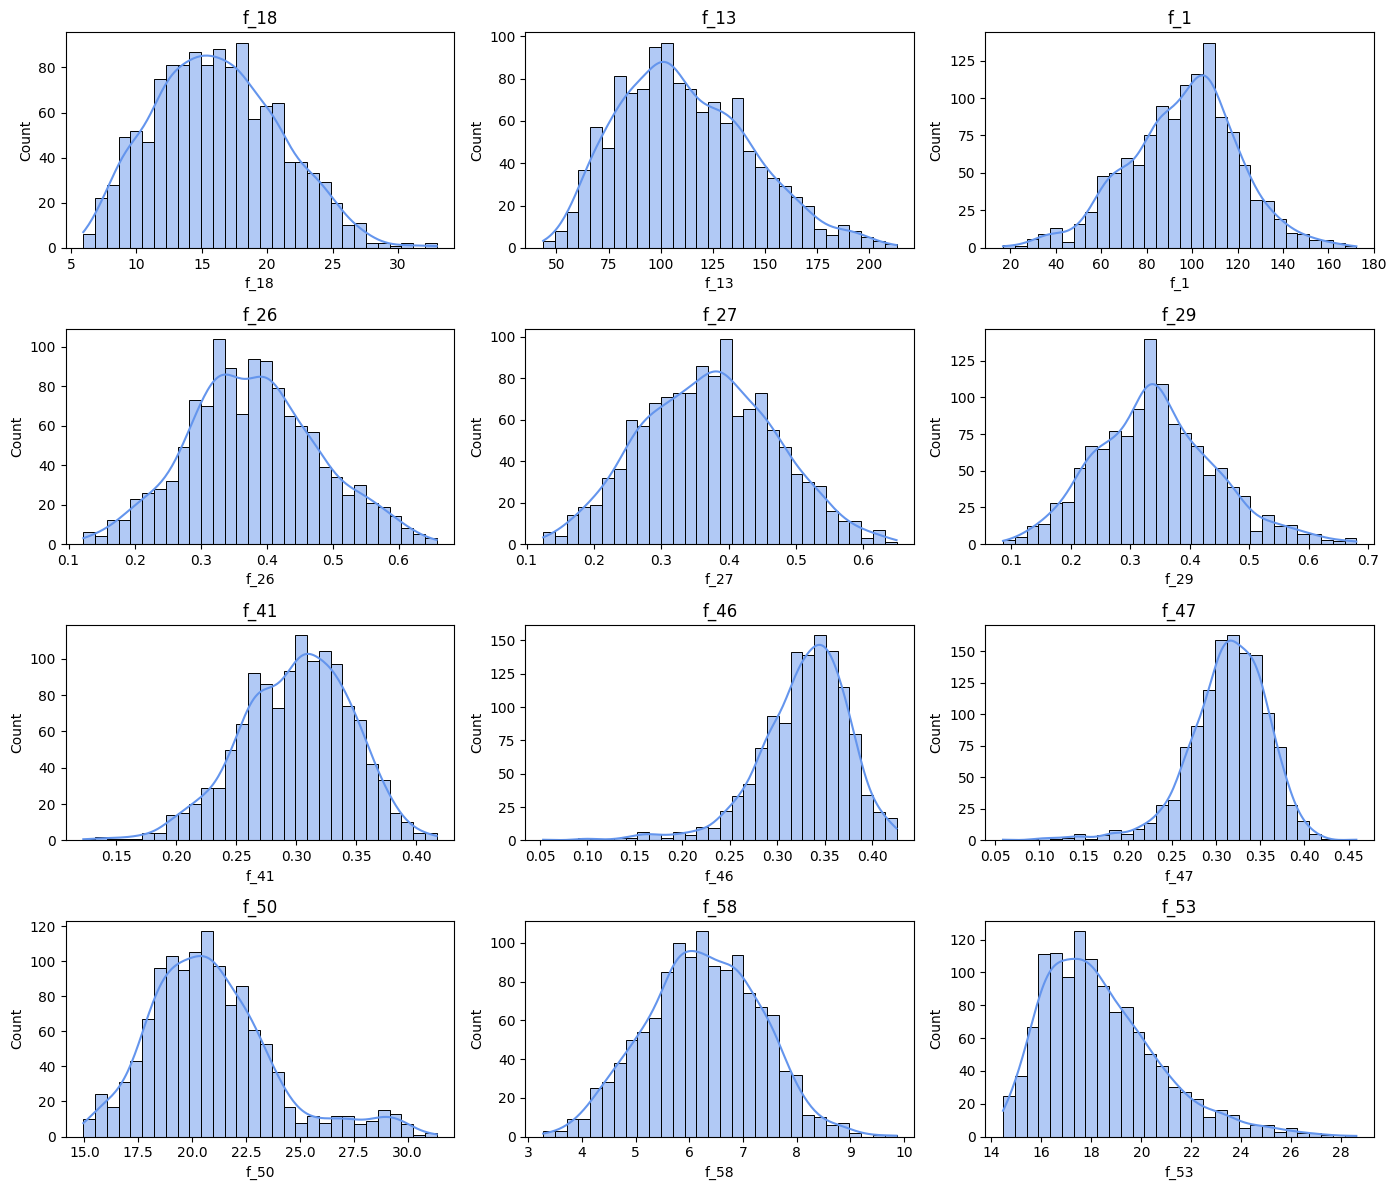

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

# --- Step 4: Smart Feature Sampling for Distribution Visualization ---

num_features = len(feature_cols)

# Option 1: Random selection of features for distribution overview
random.seed(42)
selected_features = random.sample(feature_cols, min(12, num_features))

# Option 2 (recommended): Stratified selection by feature group type
# Example heuristic: choose few from MFCC, few from Chroma, few from Spectral
mfcc_feats = [f for f in feature_cols if int(f.split('_')[1]) < 26]
chroma_feats = [f for f in feature_cols if 26 <= int(f.split('_')[1]) < 38]
spec_feats  = [f for f in feature_cols if 38 <= int(f.split('_')[1]) < 50]
other_feats = [f for f in feature_cols if int(f.split('_')[1]) >= 50]

# Select 3 random features from each group (if available)
representative_feats = []
for group in [mfcc_feats, chroma_feats, spec_feats, other_feats]:
    if len(group) > 0:
        representative_feats += random.sample(group, min(3, len(group)))

# Final list of features to visualize (use representative_feats)
features_to_plot = representative_feats if len(representative_feats) > 0 else selected_features

print("Visualizing feature distribution for these selected features:")
print(features_to_plot)

# Plot distribution histograms
plt.figure(figsize=(14, 12))
for i, col in enumerate(features_to_plot):
    plt.subplot(4, 3, i + 1)
    sns.histplot(X[col], bins=30, kde=True, color='cornflowerblue')
    plt.title(col)
plt.tight_layout()
plt.show()


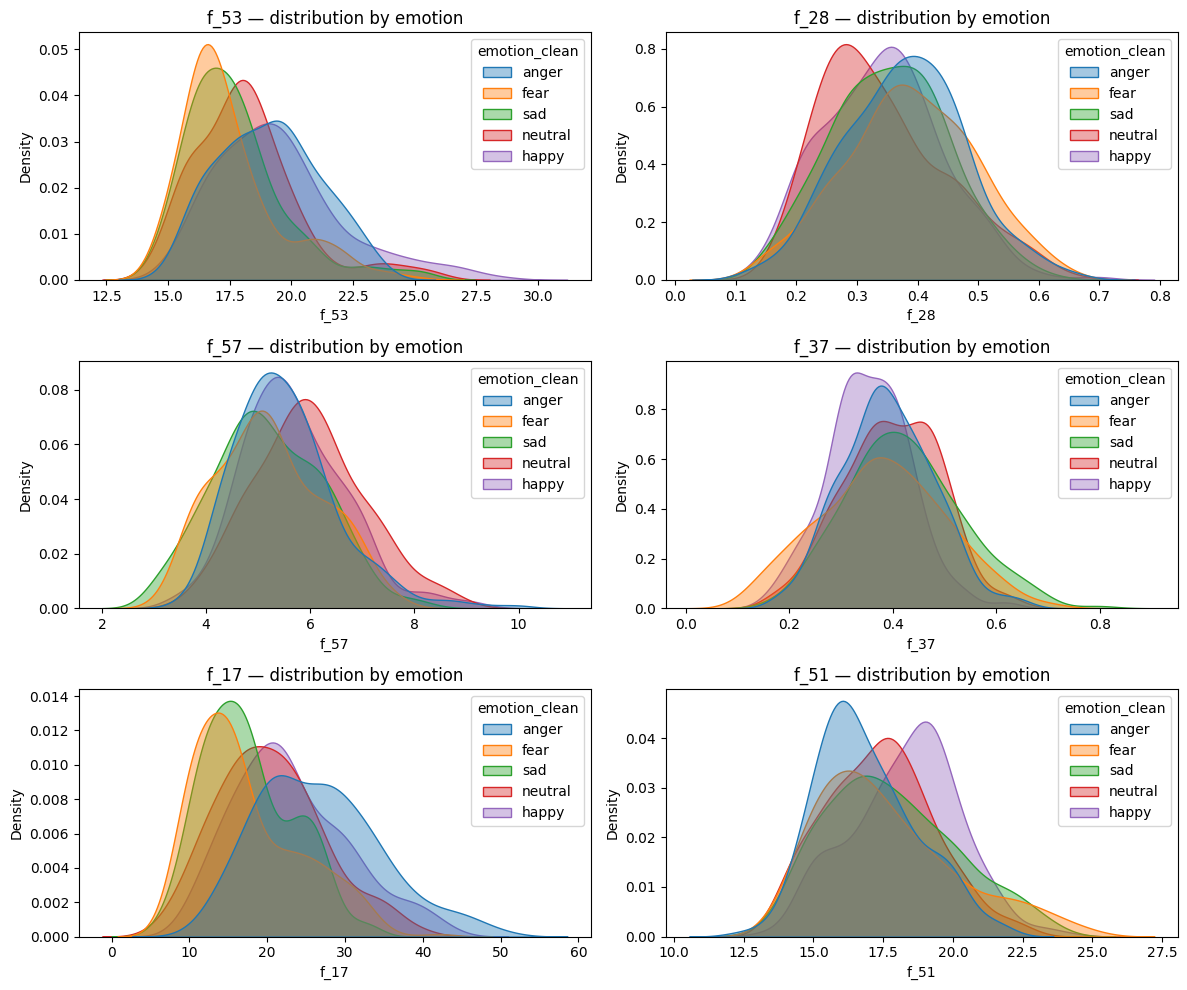

In [ ]:
plt.figure(figsize=(12, 10))
for i, col in enumerate(random.sample(feature_cols, 6)):
    plt.subplot(3, 2, i + 1)
    sns.kdeplot(data=df, x=col, hue='emotion_clean', fill=True, alpha=0.4)
    plt.title(f"{col} — distribution by emotion")
plt.tight_layout()
plt.show()


Stratified feature sample for correlation heatmap:
['f_20', 'f_3', 'f_0', 'f_23', 'f_8', 'f_29', 'f_37', 'f_28', 'f_27', 'f_34', 'f_47', 'f_44', 'f_38', 'f_49', 'f_39', 'f_56', 'f_53', 'f_58', 'f_59', 'f_50']


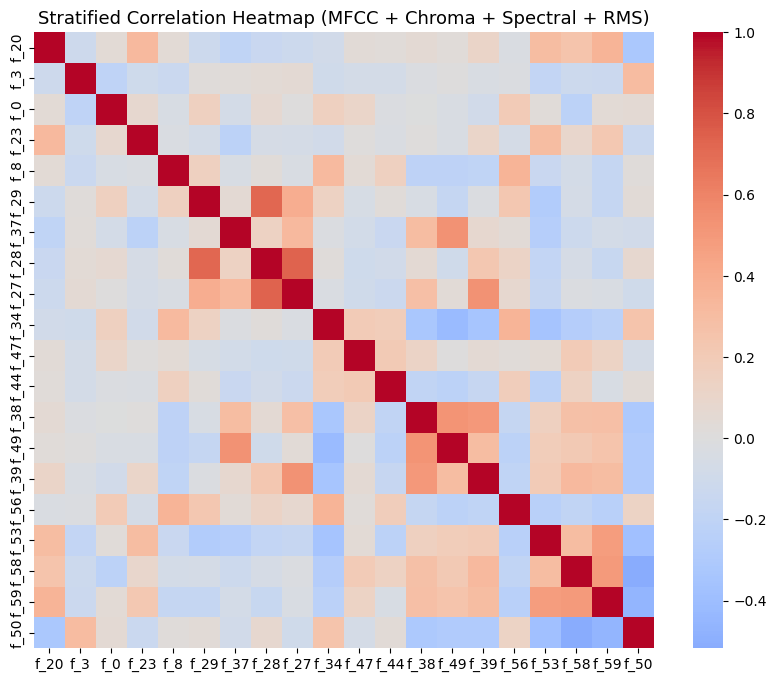

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np

# Identify approximate feature groups by index range
mfcc_feats = [f for f in feature_cols if int(f.split('_')[1]) < 26]
chroma_feats = [f for f in feature_cols if 26 <= int(f.split('_')[1]) < 38]
spec_feats  = [f for f in feature_cols if 38 <= int(f.split('_')[1]) < 50]
other_feats = [f for f in feature_cols if int(f.split('_')[1]) >= 50]

# Stratified sampling from each group (3-5 features each)
random.seed(42)
sampled_feats = []
for group in [mfcc_feats, chroma_feats, spec_feats, other_feats]:
    if len(group) > 0:
        sampled_feats += random.sample(group, min(5, len(group)))

print("Stratified feature sample for correlation heatmap:")
print(sampled_feats)

# Compute correlation matrix for stratified sample
corr_subset = X[sampled_feats].corr()

# Plot correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_subset, cmap='coolwarm', center=0, annot=False)
plt.title("Stratified Correlation Heatmap (MFCC + Chroma + Spectral + RMS)", fontsize=13)
plt.show()


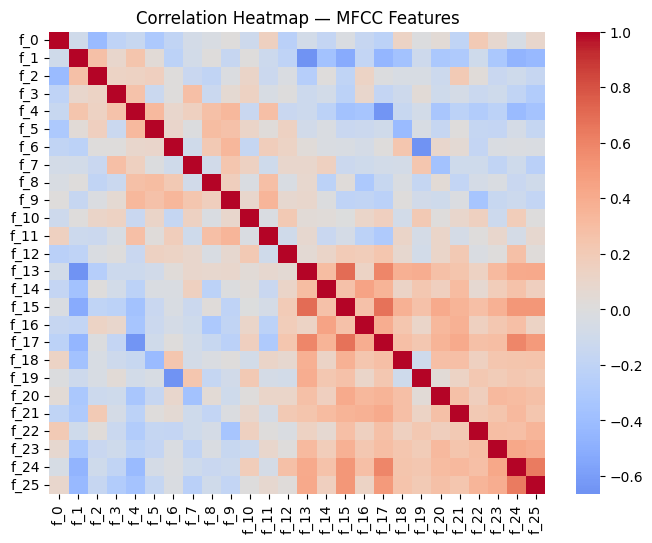

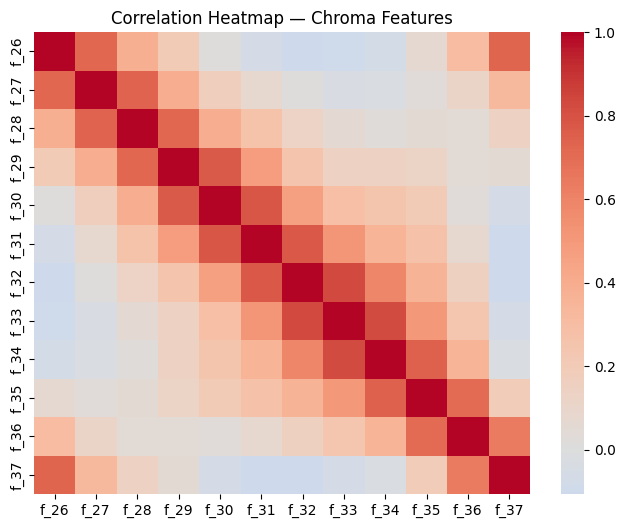

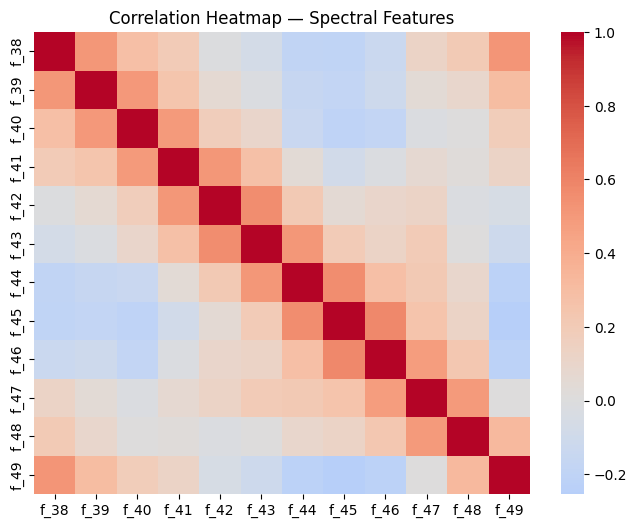

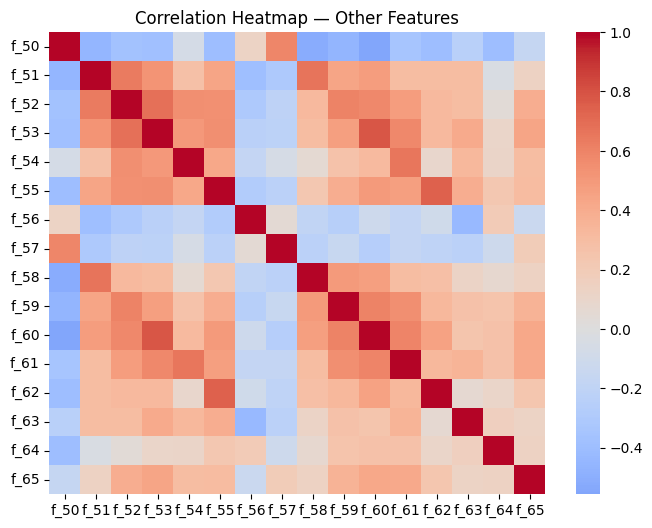

In [ ]:
for group_name, group_feats in {
    'MFCC': mfcc_feats,
    'Chroma': chroma_feats,
    'Spectral': spec_feats,
    'Other': other_feats
}.items():
    if len(group_feats) > 1:
        plt.figure(figsize=(8,6))
        sns.heatmap(X[group_feats].corr(), cmap='coolwarm', center=0)
        plt.title(f"Correlation Heatmap — {group_name} Features")
        plt.show()


#Correct EDA

Reading: /content/punjabi_audio_features_with_ids.csv
Rows: 1240 Cols: 72
Detected label column: emotion_clean
Unique emotions: ['anger' 'fear' 'sad' 'neutral' 'happy']

--- Basic stats ---
Feature count: 66
Missing values (total): 0
Saved feature descriptive stats -> /content/eda_results/feature_descriptive_stats.csv
Sampled features (for visual EDA): [np.str_('f_3'), np.str_('f_0'), np.str_('f_11'), np.str_('f_4'), np.str_('f_16'), np.str_('f_24'), np.str_('f_21'), np.str_('f_28'), np.str_('f_18'), np.str_('f_27'), np.str_('f_36'), np.str_('f_43'), np.str_('f_40'), np.str_('f_34'), np.str_('f_46'), np.str_('f_52'), np.str_('f_53'), np.str_('f_64'), np.str_('f_58'), np.str_('f_59')]


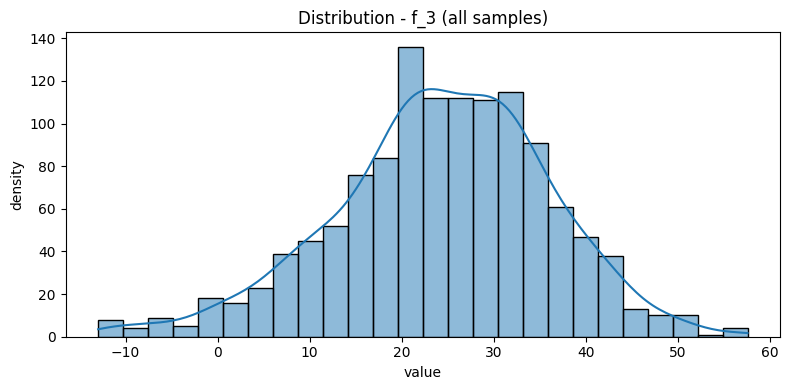

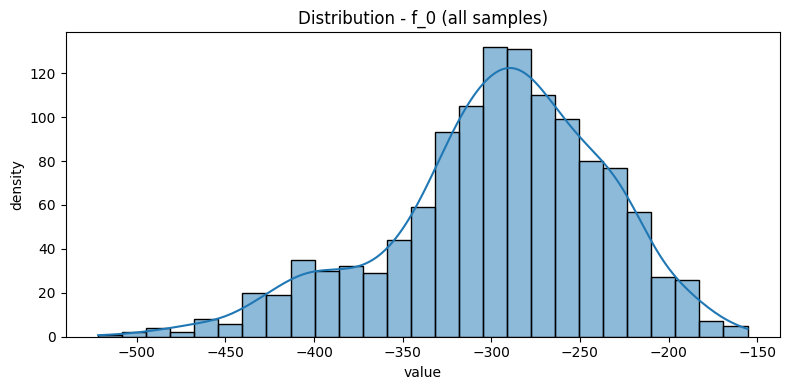

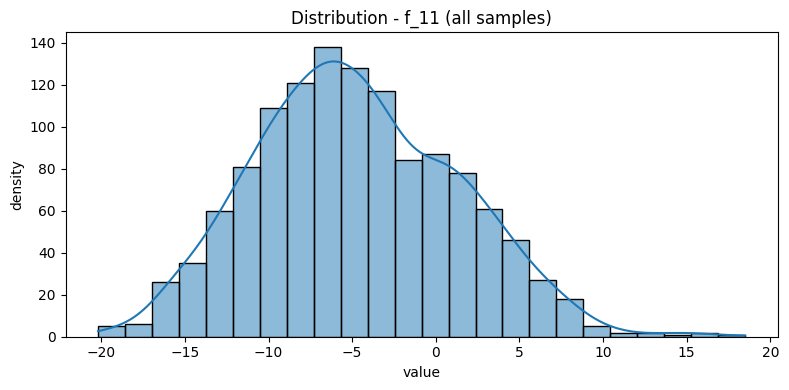

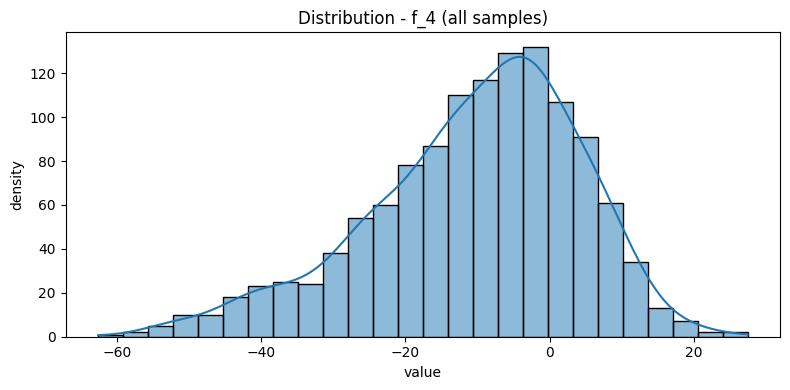

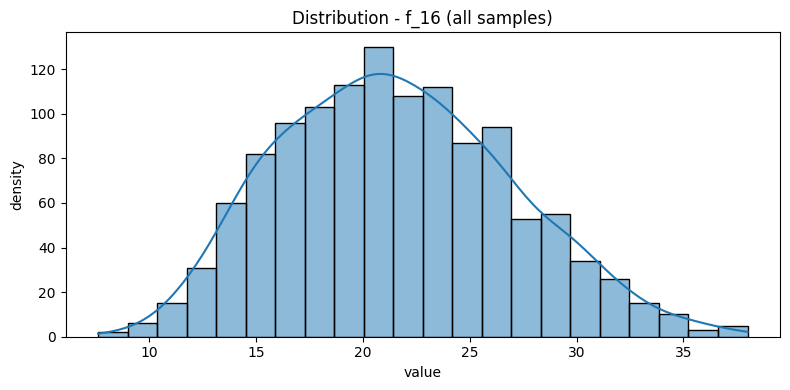

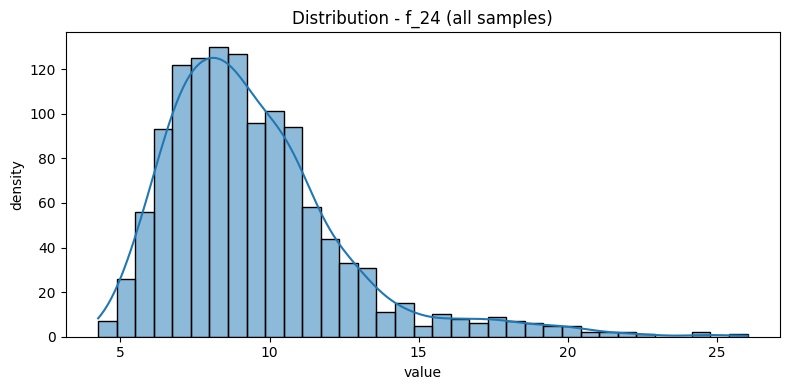

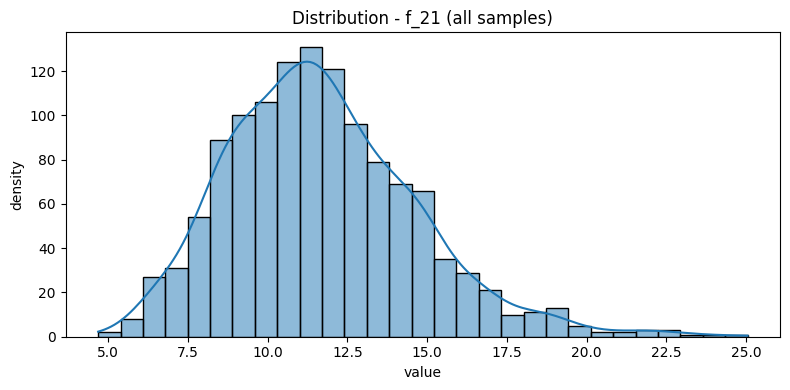

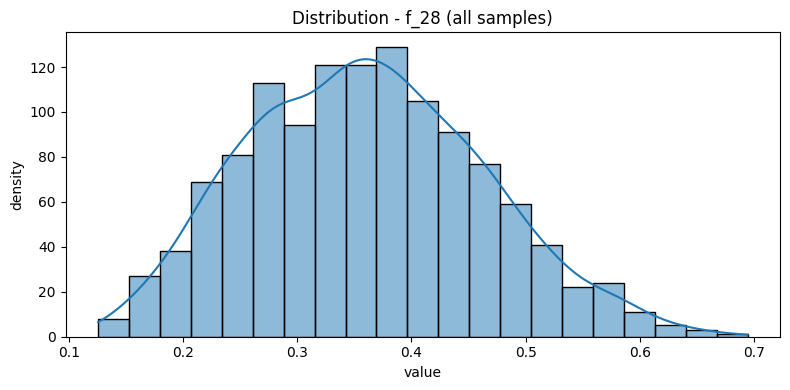

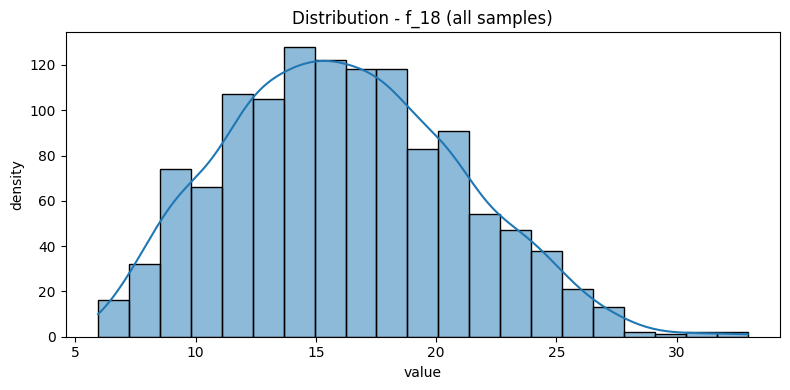

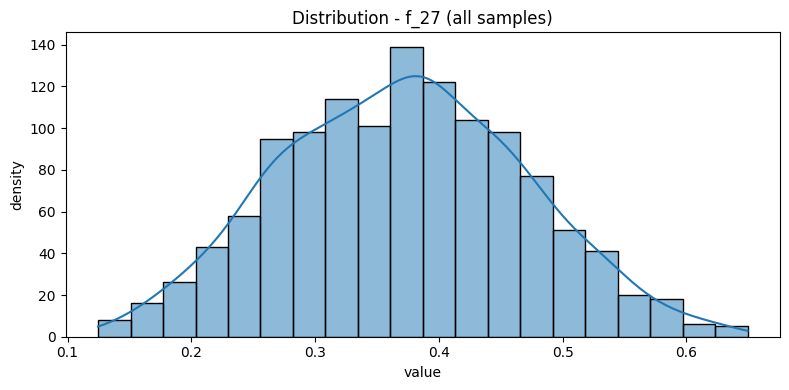

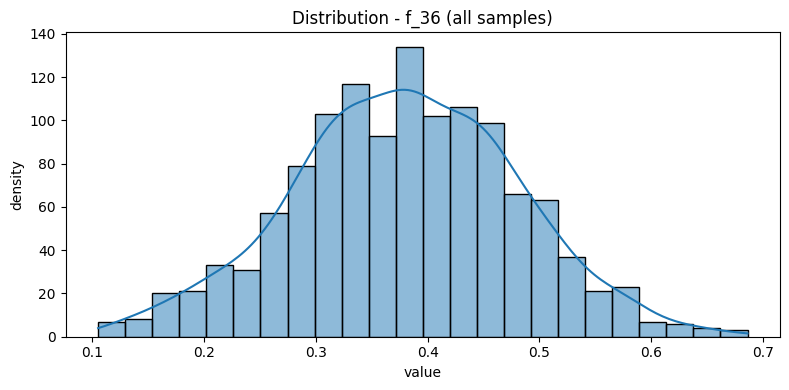

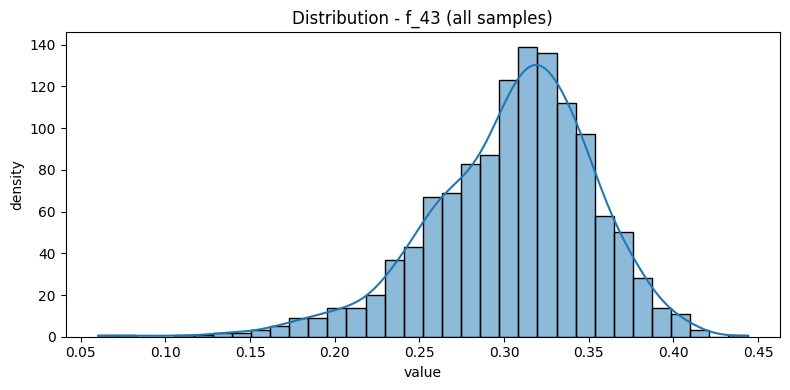

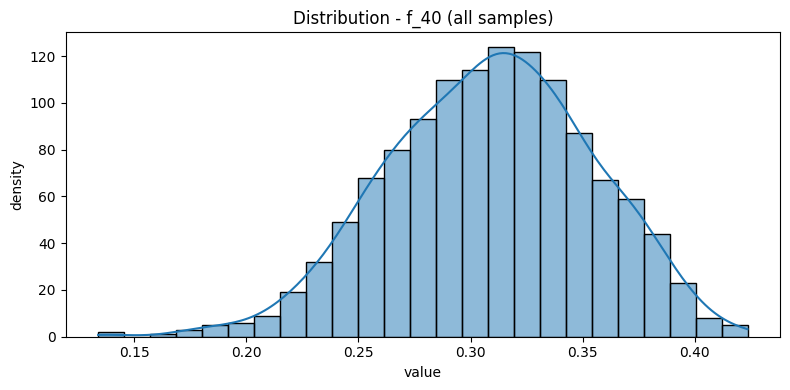

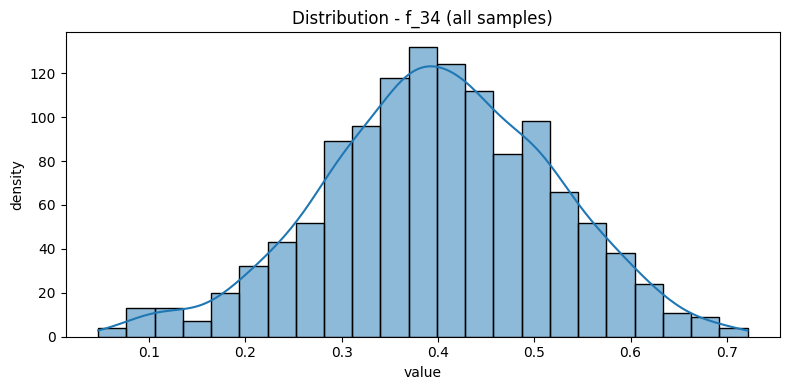

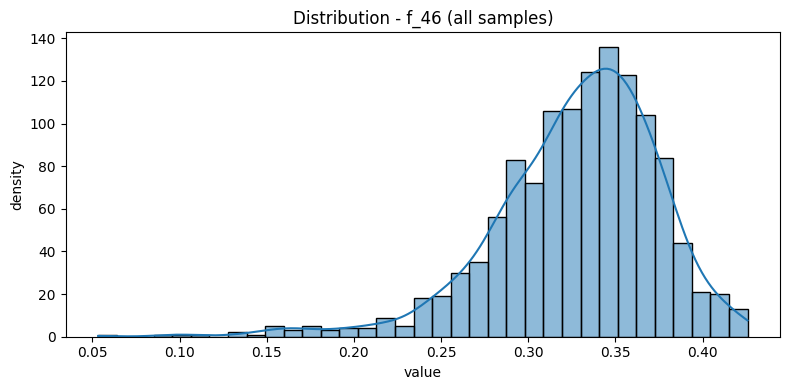

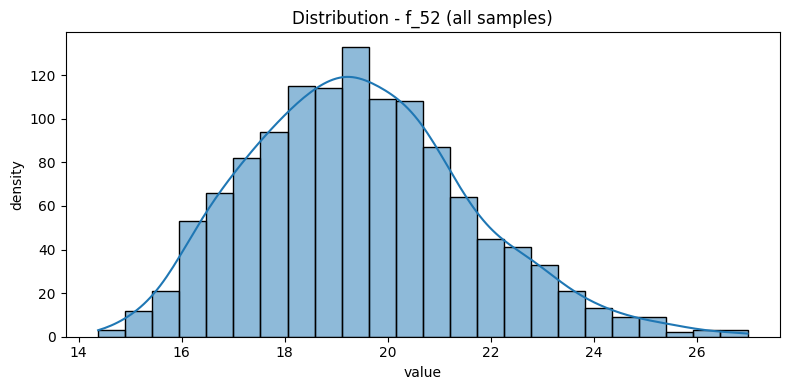

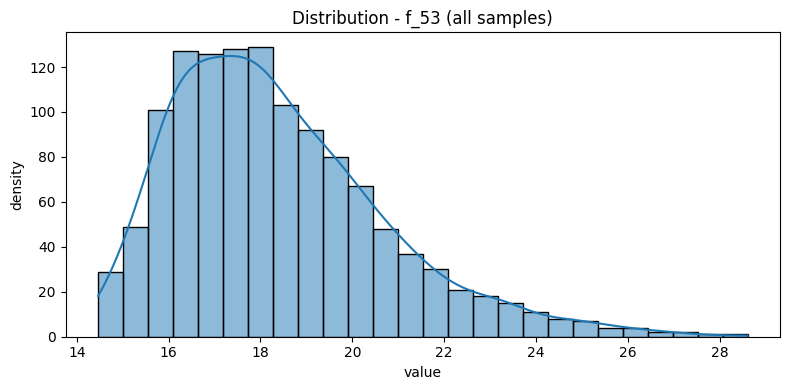

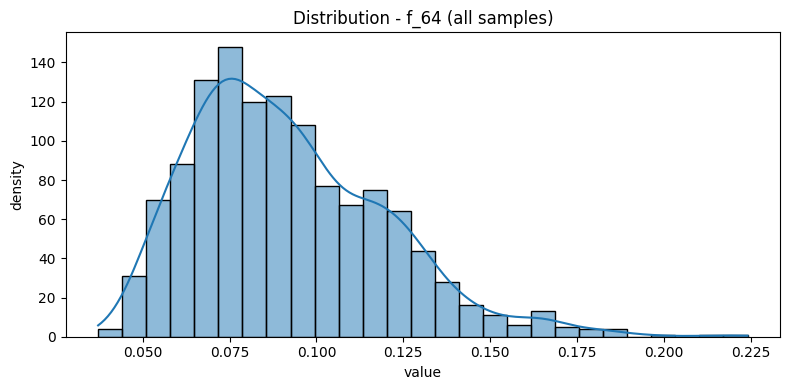

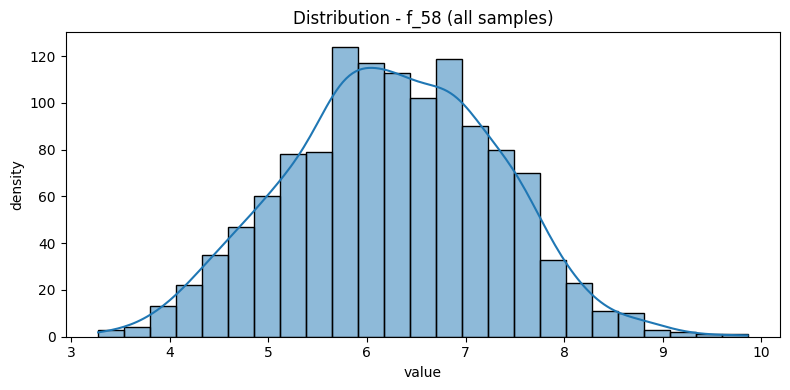

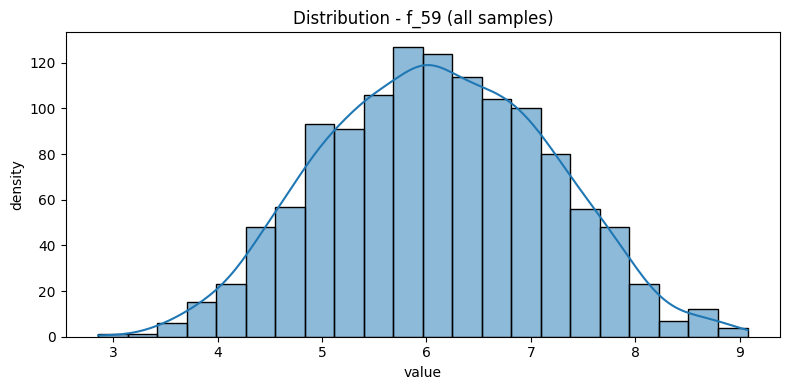

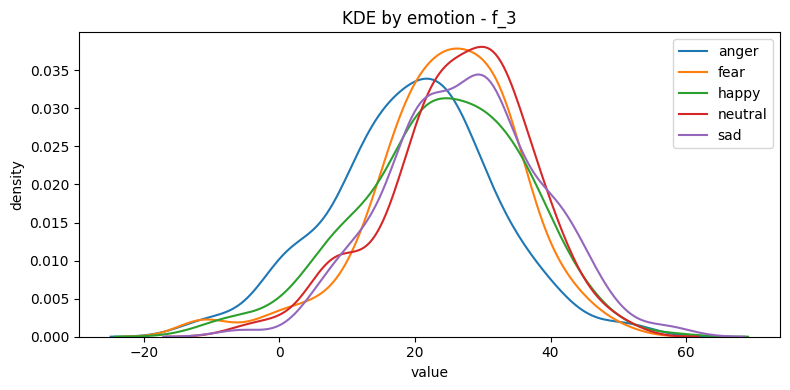

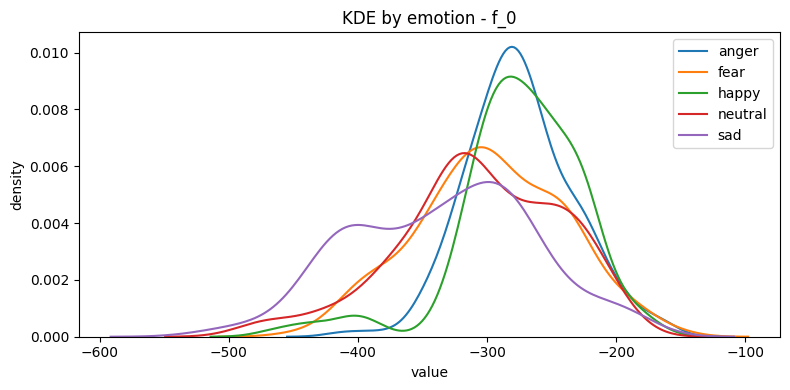

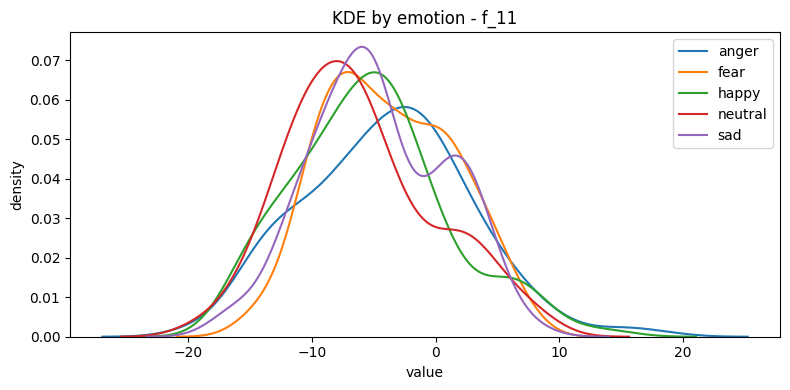

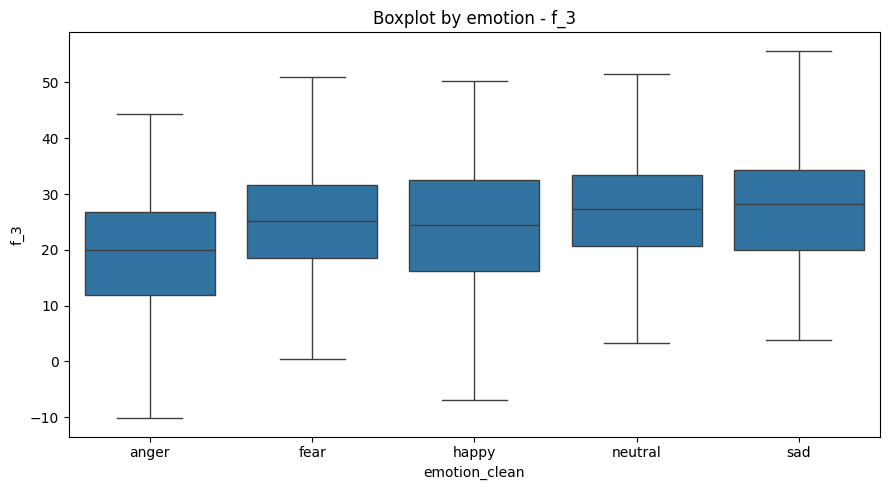

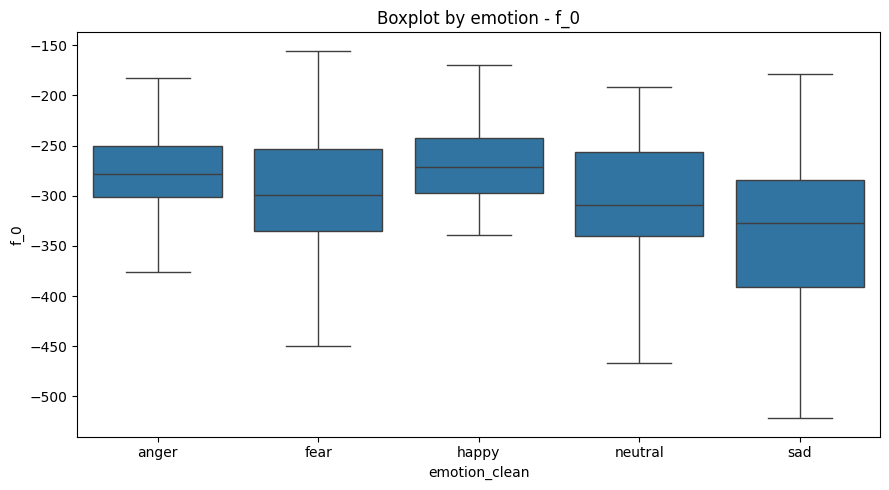

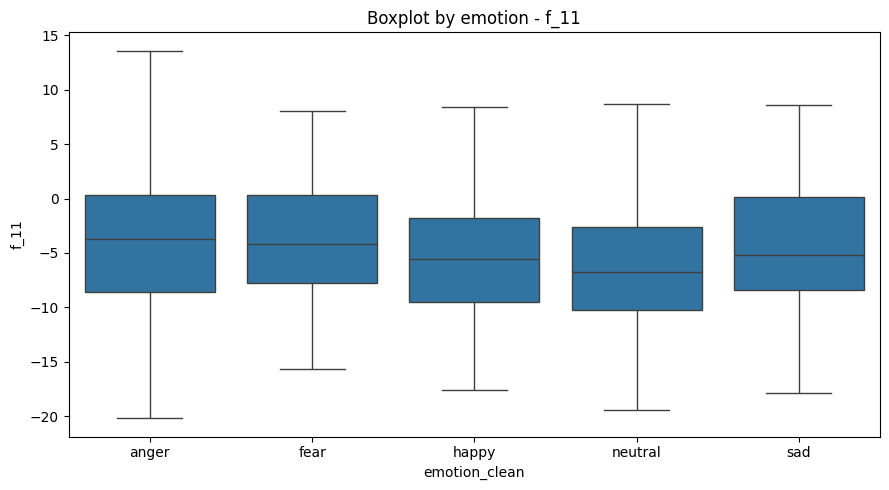

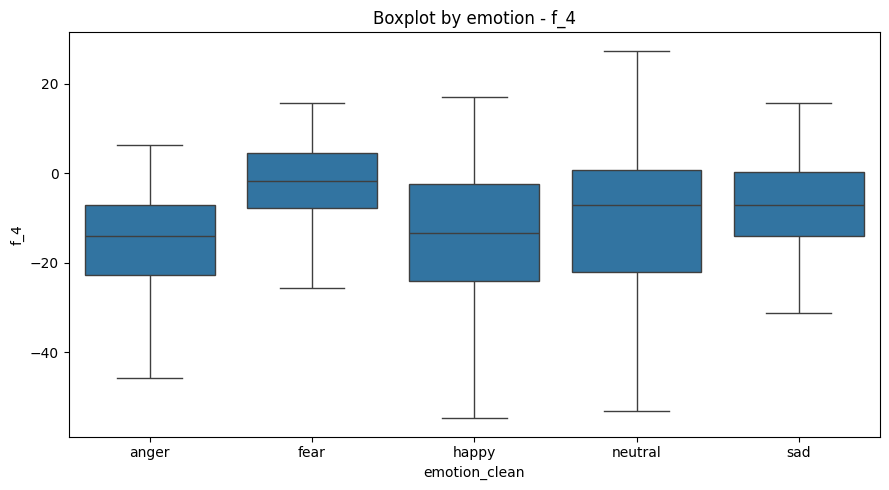

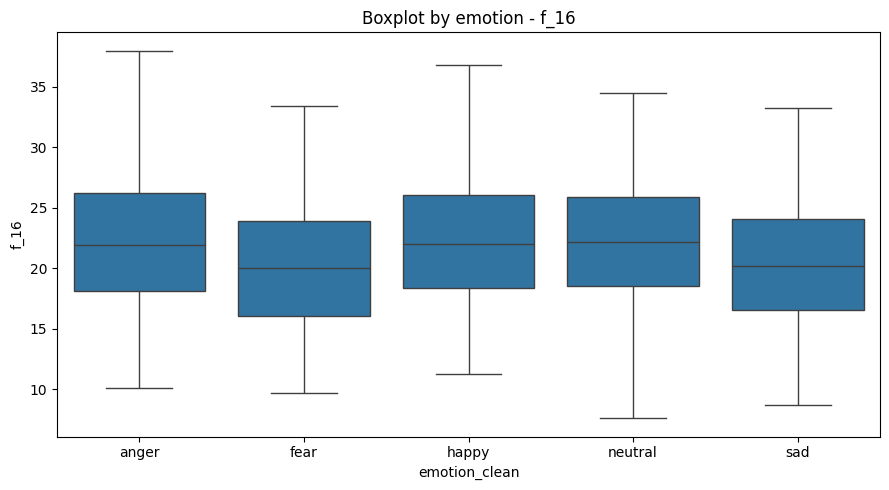

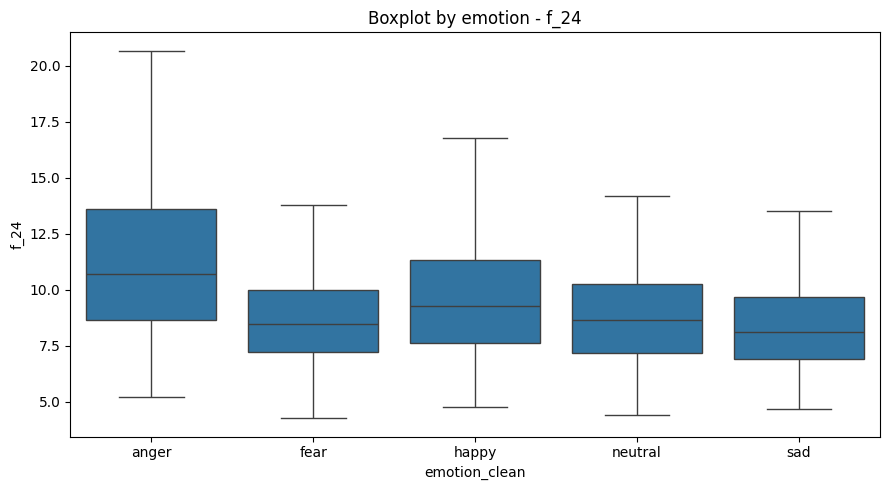

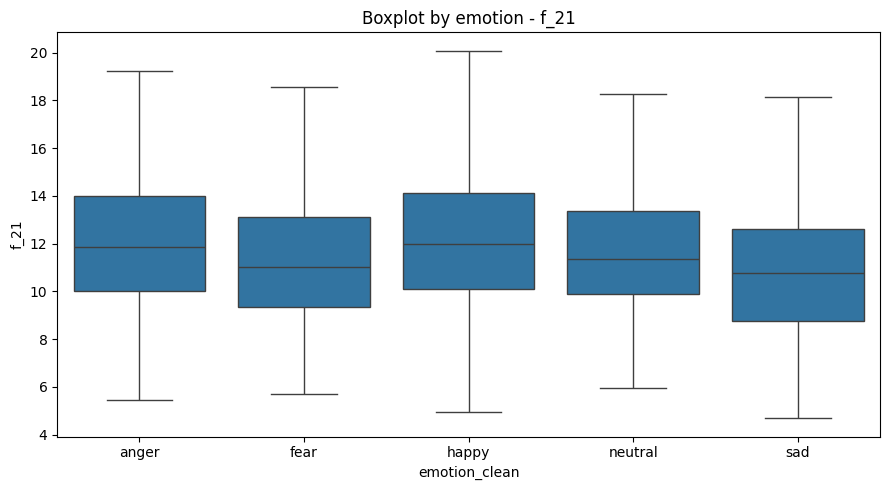

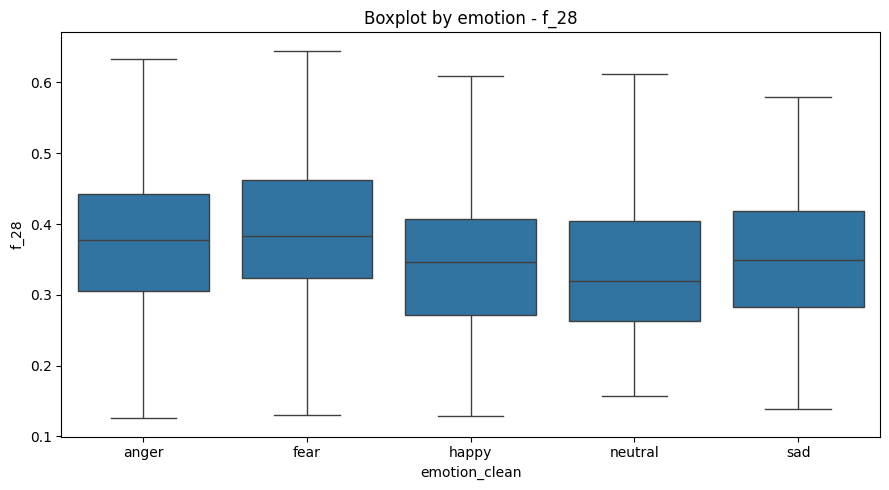

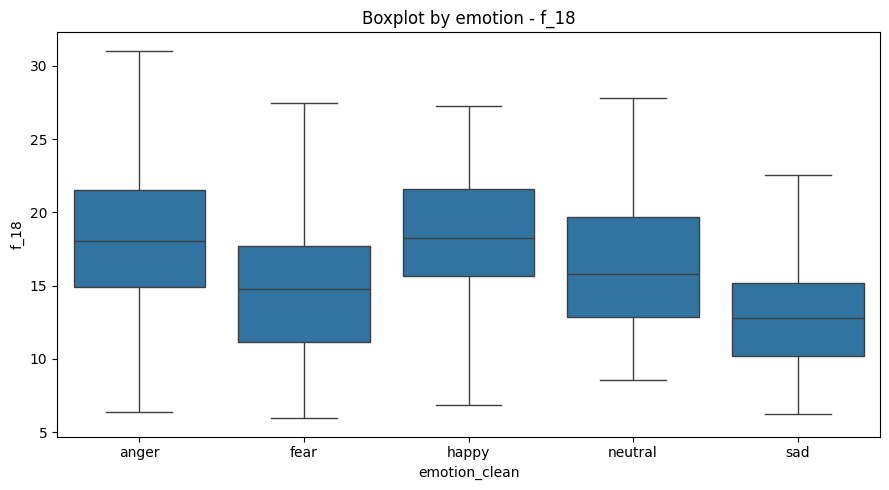

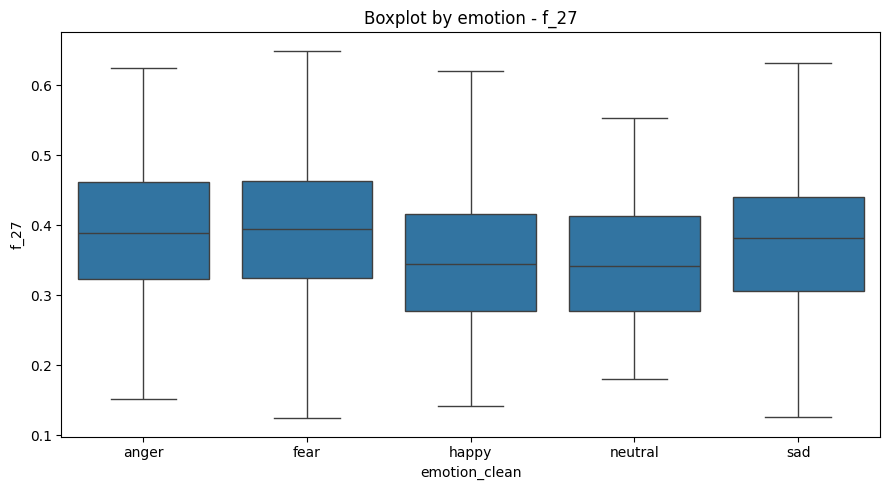

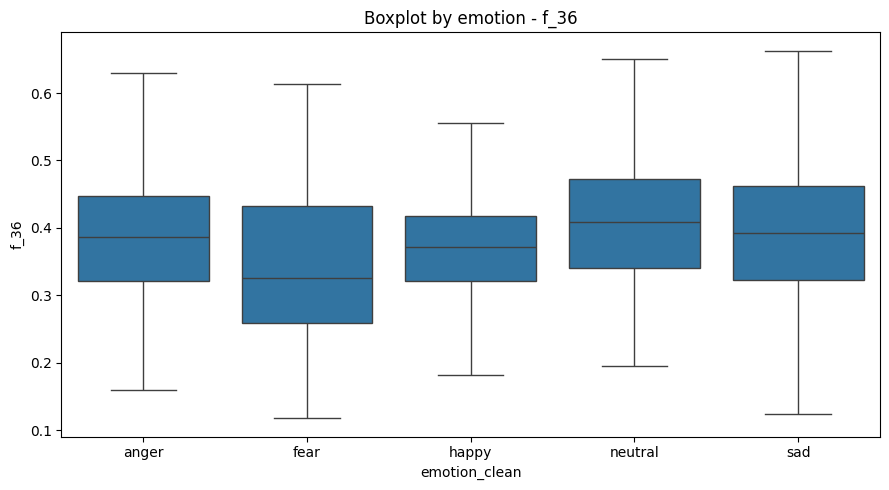

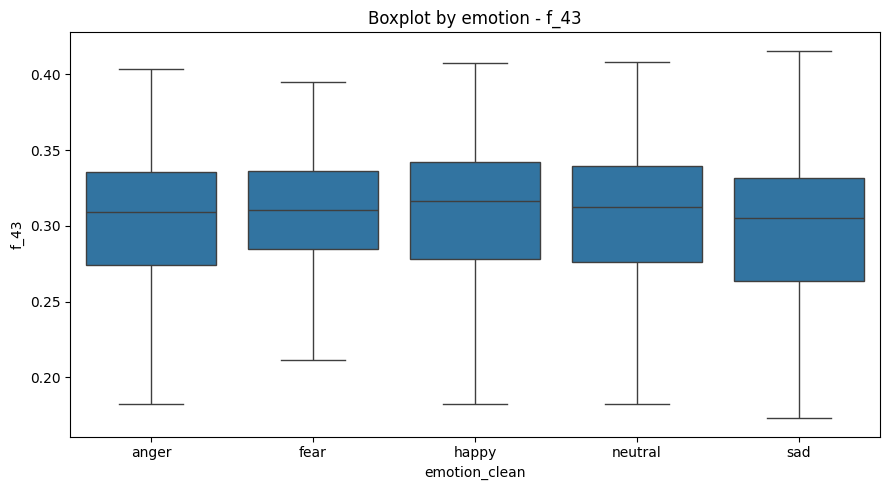

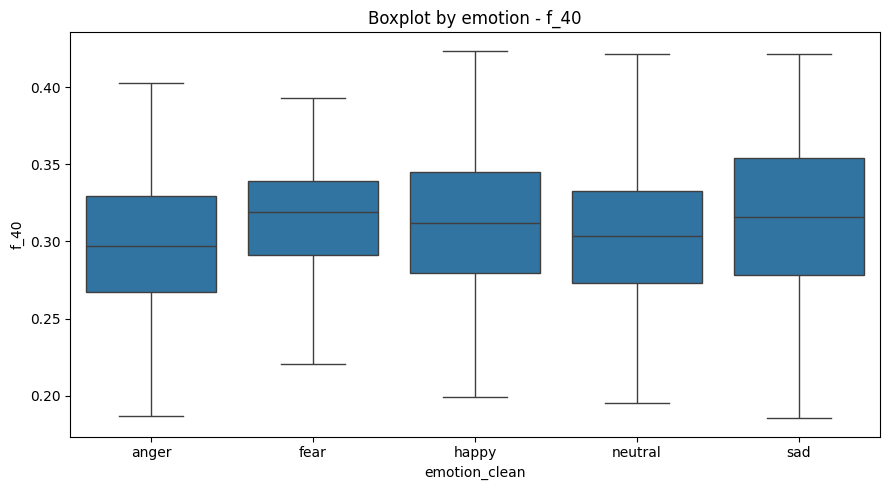

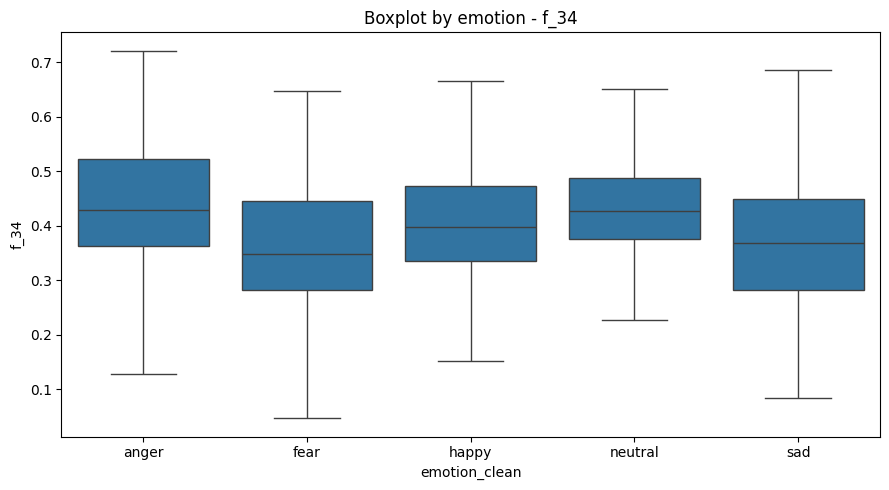

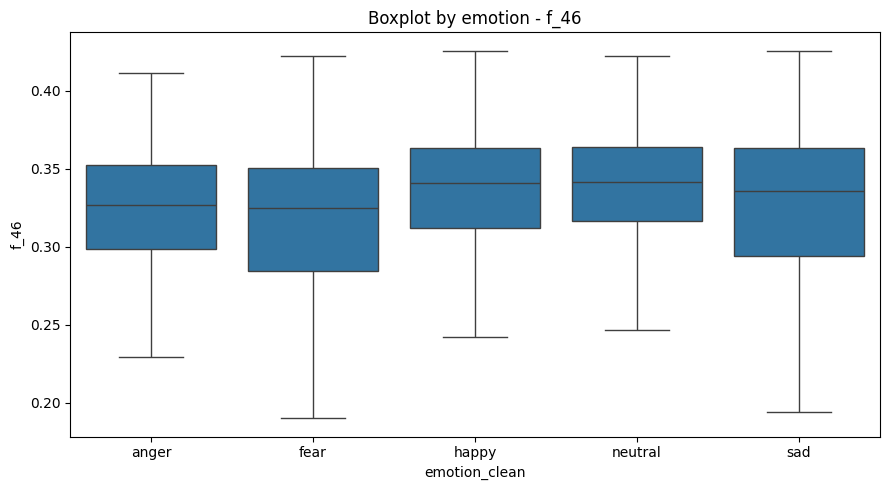

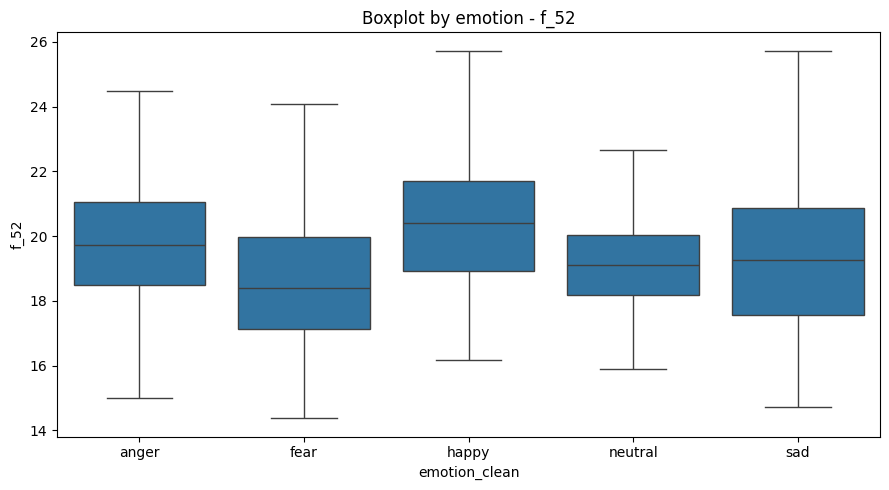

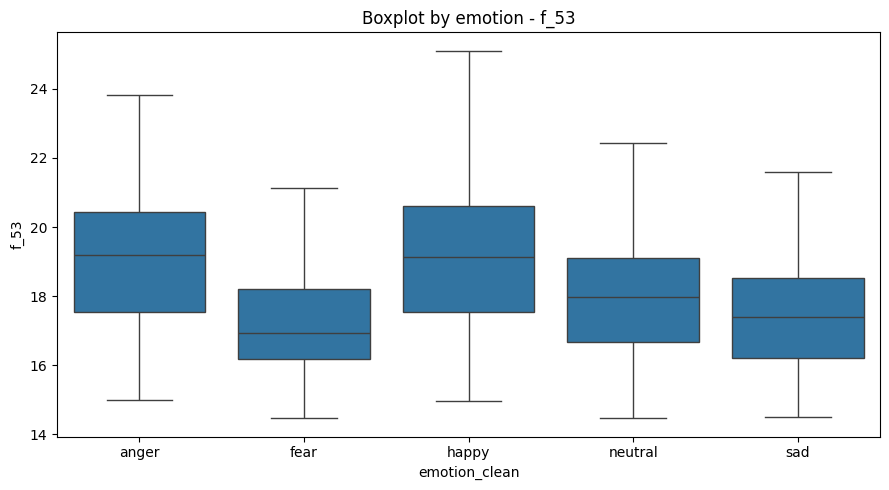

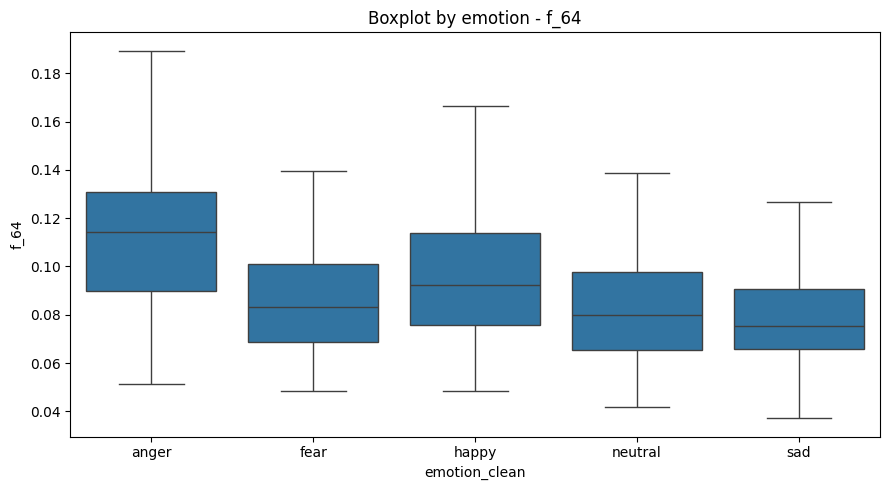

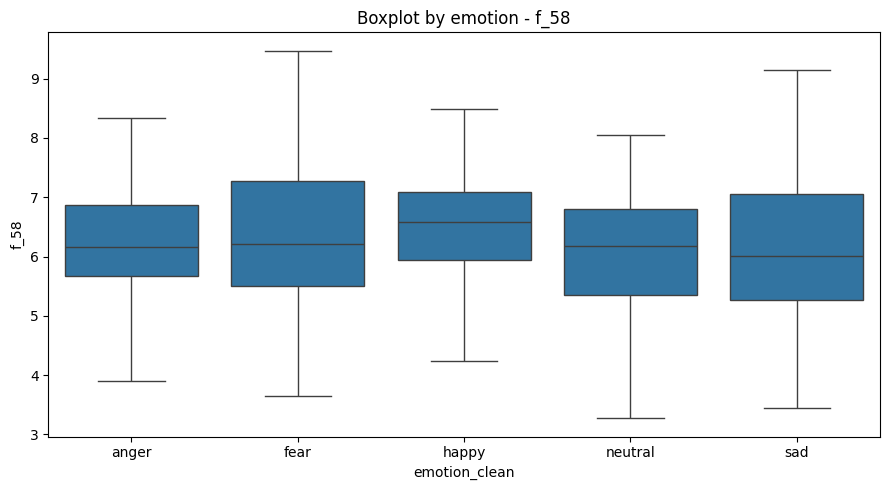

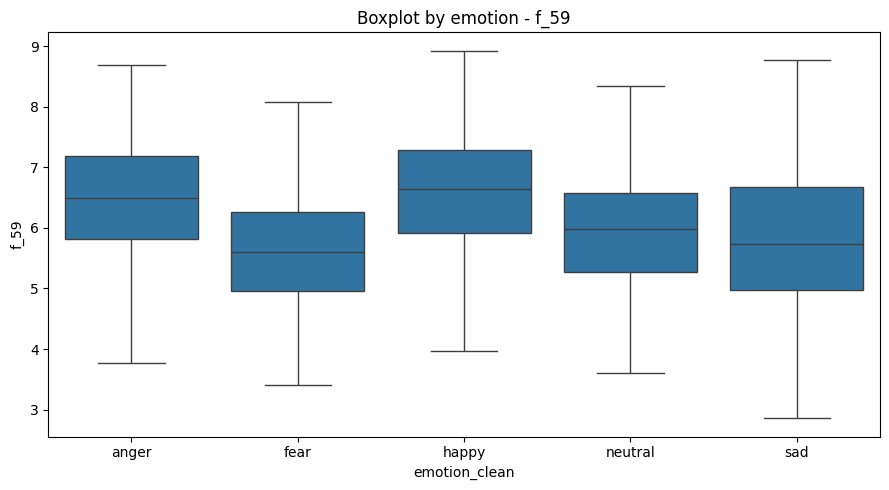

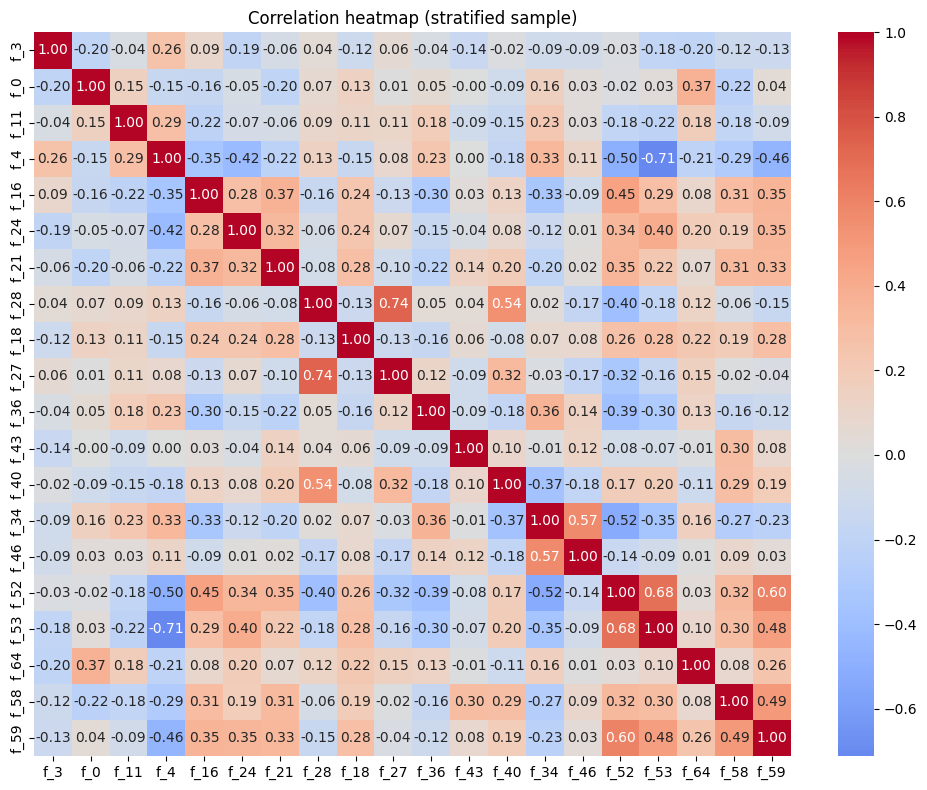

Found 0 pairs with |corr| > 0.9. Saved to high_corr_pairs_90.csv
Unique features implicated in high-correlation pairs: 0


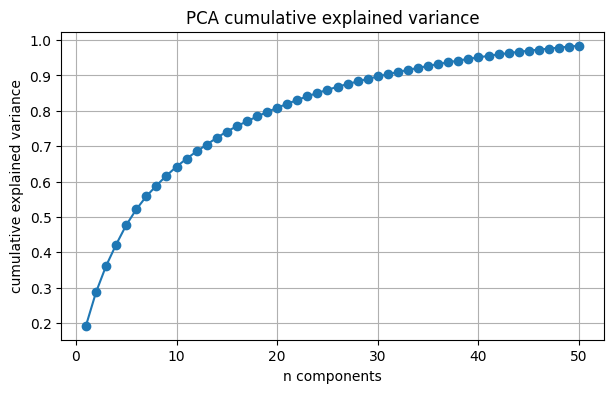

Saved feature importances -> /content/eda_results/feature_importances_rf.csv


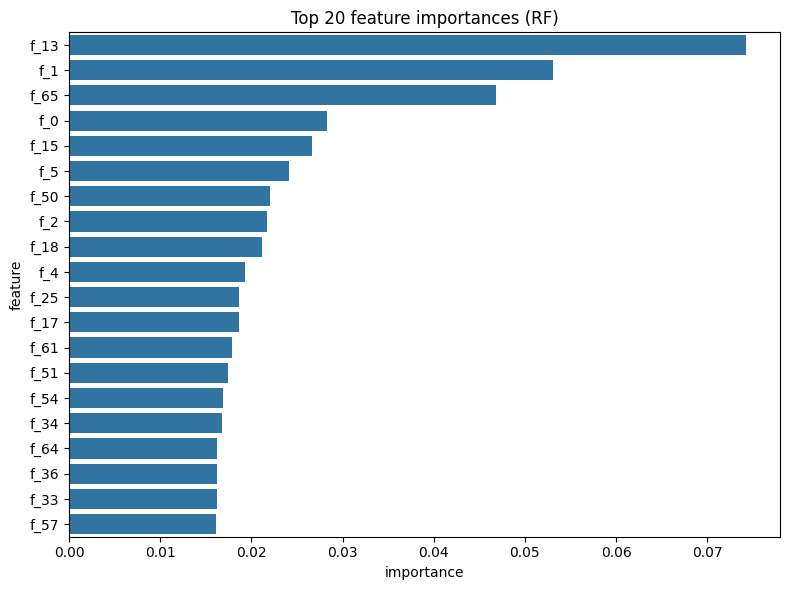


EDA complete. All artifacts saved to: /content/eda_results
Artifacts to review: feature_descriptive_stats.csv, sampled_features.txt, hist_*.png, kde_by_emotion_*.png, box_*.png, corr_subset.csv, corr_subset_heatmap.png, full_correlation_matrix_abs.csv, high_corr_pairs_90.csv, high_corr_features.txt, pca_explained.csv, pca_explained.png, feature_importances_rf.csv, top20_importances.png


In [ ]:
# EDA (stratified sampling) for your audio-feature CSV
# Paste in Colab. Set FEATURES_CSV to your features CSV path first.

FEATURES_CSV = '/content/punjabi_audio_features_with_ids.csv'  # <- change if needed
OUT_DIR = '/content/eda_results'                             # outputs go here

# ----------------------------
# Requirements: pandas, numpy, matplotlib, seaborn, sklearn
# (Colab usually has these installed; otherwise !pip install them)
# ----------------------------
import os, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

os.makedirs(OUT_DIR, exist_ok=True)
print("Reading:", FEATURES_CSV)
df = pd.read_csv(FEATURES_CSV)
print("Rows:", len(df), "Cols:", len(df.columns))

# 1) Identify feature columns and label
feature_cols = [c for c in df.columns if c.startswith('f_')]
if len(feature_cols) == 0:
    raise RuntimeError("No columns starting with 'f_' found. Adjust feature_col detection.")

# label column detection
if 'emotion_clean' in df.columns:
    label_col = 'emotion_clean'
else:
    onehot = [c for c in df.columns if c.startswith('emotion_')]
    if len(onehot)>0:
        df['emotion_clean'] = df[onehot].idxmax(axis=1).str.replace('emotion_','')
        label_col = 'emotion_clean'
    else:
        if 'label_id' in df.columns:
            df['emotion_clean'] = df['label_id'].astype(str)
            label_col = 'emotion_clean'
        else:
            raise RuntimeError("No emotion label column found. Provide 'emotion_clean' or one-hot columns.")

print("Detected label column:", label_col)
print("Unique emotions:", df[label_col].unique())

X = df[feature_cols].copy()
y = df[label_col].copy()

# ----------------------------
# Basic stats & missing values
# ----------------------------
print("\n--- Basic stats ---")
print("Feature count:", X.shape[1])
print("Missing values (total):", X.isna().sum().sum())
desc = X.describe().T
desc['variance'] = X.var()
desc.to_csv(os.path.join(OUT_DIR, 'feature_descriptive_stats.csv'))
print("Saved feature descriptive stats ->", os.path.join(OUT_DIR, 'feature_descriptive_stats.csv'))

# ----------------------------
# Stratified feature sampling by index quartiles (representative)
# ----------------------------
# Expect names f_<index>; get numeric index and sort
feat_with_idx = []
for c in feature_cols:
    try:
        idx = int(c.split('_')[1])
    except:
        idx = None
    feat_with_idx.append((c, idx))
# Sort by numeric index where possible; unknowns at end
feat_with_idx = sorted(feat_with_idx, key=lambda x: (x[1] is None, x[1] if x[1] is not None else 10**9))
sorted_feats = [c for c,_ in feat_with_idx]
# split into 4 groups by position
groups = np.array_split(sorted_feats, 4)
random.seed(42)
sampled_feats = []
for g in groups:
    if len(g) > 0:
        sampled_feats += random.sample(list(g), min(5, len(g)))
# dedupe
sampled_feats = list(dict.fromkeys(sampled_feats))
print("Sampled features (for visual EDA):", sampled_feats)
with open(os.path.join(OUT_DIR, 'sampled_features.txt'),'w') as fh:
    fh.write("\n".join(sampled_feats))

# ----------------------------
# Plot histograms and KDE (one figure per feature)
# ----------------------------
for feat in sampled_feats:
    plt.figure(figsize=(8,4))
    sns.histplot(X[feat].dropna(), kde=True)   # distribution overall
    plt.title(f"Distribution - {feat} (all samples)")
    plt.xlabel('value'); plt.ylabel('density')
    plt.tight_layout()
    p = os.path.join(OUT_DIR, f'hist_{feat}.png'); plt.savefig(p); plt.show(); plt.close()

# Emotion-wise KDE plots (overlay) for a subset (3 features)
for feat in sampled_feats[:3]:
    plt.figure(figsize=(8,4))
    for em in sorted(df[label_col].unique()):
        sns.kdeplot(data=df[df[label_col]==em], x=feat, label=str(em), fill=False)
    plt.title(f"KDE by emotion - {feat}")
    plt.xlabel('value'); plt.ylabel('density')
    plt.legend(loc='best')
    plt.tight_layout()
    p = os.path.join(OUT_DIR, f'kde_by_emotion_{feat}.png'); plt.savefig(p); plt.show(); plt.close()

# Boxplot (by emotion) per sampled feature (single figure each)
for feat in sampled_feats:
    plt.figure(figsize=(9,5))
    order = sorted(df[label_col].unique())
    sns.boxplot(x=label_col, y=feat, data=df, order=order, showfliers=False)
    plt.title(f"Boxplot by emotion - {feat}")
    plt.tight_layout()
    p = os.path.join(OUT_DIR, f'box_{feat}.png'); plt.savefig(p); plt.show(); plt.close()

# ----------------------------
# Correlation (stratified subset & full)
# ----------------------------
corr_subset = X[sampled_feats].corr()
corr_subset.to_csv(os.path.join(OUT_DIR, 'corr_subset.csv'))

plt.figure(figsize=(10,8))
sns.heatmap(corr_subset, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title("Correlation heatmap (stratified sample)")
plt.tight_layout()
p = os.path.join(OUT_DIR, 'corr_subset_heatmap.png'); plt.savefig(p); plt.show(); plt.close()

# Full correlation matrix absolute
corr_full = X.corr().abs()
corr_full.to_csv(os.path.join(OUT_DIR, 'full_correlation_matrix_abs.csv'))

# Find pairs with |corr| > threshold
TH = 0.90
upper = corr_full.where(np.triu(np.ones(corr_full.shape), k=1).astype(bool))
pairs = []
for col in upper.columns:
    high = upper[col][upper[col] > TH]
    for idx, val in high.items():
        pairs.append((idx, col, float(val)))
pairs_df = pd.DataFrame(pairs, columns=['feature_1','feature_2','abs_corr']).sort_values('abs_corr', ascending=False)
pairs_df.to_csv(os.path.join(OUT_DIR, f'high_corr_pairs_{int(TH*100)}.csv'), index=False)
print(f"Found {len(pairs_df)} pairs with |corr| > {TH}. Saved to high_corr_pairs_{int(TH*100)}.csv")

# Also save unique features involved
unique_high = sorted(set(pairs_df['feature_1']).union(set(pairs_df['feature_2'])))
with open(os.path.join(OUT_DIR, 'high_corr_features.txt'),'w') as fh:
    fh.write("\n".join(unique_high))
print("Unique features implicated in high-correlation pairs:", len(unique_high))

# ----------------------------
# PCA explained variance (use scaled features)
# ----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.fillna(0))
n_comp = min(50, X_scaled.shape[1])
pca = PCA(n_components=n_comp, random_state=42)
pca.fit(X_scaled)
cumvar = np.cumsum(pca.explained_variance_ratio_)
pd.DataFrame({'n_components': range(1, len(cumvar)+1), 'cumvar': cumvar}).to_csv(os.path.join(OUT_DIR,'pca_explained.csv'), index=False)

plt.figure(figsize=(7,4))
plt.plot(range(1,len(cumvar)+1), cumvar, marker='o')
plt.xlabel('n components'); plt.ylabel('cumulative explained variance')
plt.title('PCA cumulative explained variance')
plt.grid(True)
p = os.path.join(OUT_DIR, 'pca_explained.png'); plt.savefig(p); plt.show(); plt.close()

# ----------------------------
# Feature importance (RandomForest)
# ----------------------------
le = LabelEncoder()
y_enc = le.fit_transform(df[label_col])
rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
rf.fit(X.fillna(0), y_enc)
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
imp_df.to_csv(os.path.join(OUT_DIR,'feature_importances_rf.csv'), index=False)
print("Saved feature importances ->", os.path.join(OUT_DIR,'feature_importances_rf.csv'))

# Plot top 20
top20 = imp_df.head(20)
plt.figure(figsize=(8,6))
sns.barplot(x='importance', y='feature', data=top20)
plt.title('Top 20 feature importances (RF)')
plt.tight_layout()
p = os.path.join(OUT_DIR,'top20_importances.png'); plt.savefig(p); plt.show(); plt.close()

print("\nEDA complete. All artifacts saved to:", OUT_DIR)
print("Artifacts to review: feature_descriptive_stats.csv, sampled_features.txt, hist_*.png, kde_by_emotion_*.png, box_*.png, corr_subset.csv, corr_subset_heatmap.png, full_correlation_matrix_abs.csv, high_corr_pairs_90.csv, high_corr_features.txt, pca_explained.csv, pca_explained.png, feature_importances_rf.csv, top20_importances.png")


In [ ]:
# Zip the folder
!zip -r /content/eda_results.zip /content/eda_results

# Download it
from google.colab import files
files.download('/content/eda_results.zip')


  adding: content/eda_results/ (stored 0%)
  adding: content/eda_results/hist_f_40.png (deflated 7%)
  adding: content/eda_results/high_corr_pairs_90.csv (deflated 14%)
  adding: content/eda_results/full_correlation_matrix_abs.csv (deflated 62%)
  adding: content/eda_results/box_f_28.png (deflated 21%)
  adding: content/eda_results/hist_f_18.png (deflated 7%)
  adding: content/eda_results/hist_f_24.png (deflated 7%)
  adding: content/eda_results/box_f_58.png (deflated 21%)
  adding: content/eda_results/hist_f_52.png (deflated 7%)
  adding: content/eda_results/box_f_0.png (deflated 20%)
  adding: content/eda_results/hist_f_64.png (deflated 7%)
  adding: content/eda_results/hist_f_21.png (deflated 7%)
  adding: content/eda_results/box_f_40.png (deflated 22%)
  adding: content/eda_results/pca_explained.csv (deflated 48%)
  adding: content/eda_results/hist_f_3.png (deflated 7%)
  adding: content/eda_results/hist_f_34.png (deflated 7%)
  adding: content/eda_results/box_f_4.png (deflated 22%

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>